In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")

print("Path to dataset files:", path)

c:\Users\cyber\Downloads\Personal Project\Stocks\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 522M/522M [01:07<00:00, 8.15MB/s] 

Extracting files...


Path to dataset files: C:\Users\cyber\.cache\kagglehub\datasets\jacksoncrow\stock-market-dataset\versions\2


In [6]:
!pip uninstall pinecone-client
!pip install pinecone

^C
                                              0.0/421.9 kB ? eta -:--:--
     ------------------------------------- 421.9/421.9 kB 12.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
pip install embeddings-util

                                              0.0/186.0 kB ? eta -:--:--
     ------------------------------------- 186.0/186.0 kB 11.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pinecone import pinecone
import openai
import dotenv
import os
import tqdm
from dotenv import load_dotenv
from datetime import datetime

In [2]:
load_dotenv()

True

In [34]:
ETFS = []
STOCKS = []
for file in os.listdir(path):

    if file.endswith(".csv"):
        df = pd.read_csv(path + "/" + file)
        print(df.head())
        print(df.describe())
    else:
        STOCKS = os.listdir(path + "/" + "stocks")
        ETFS = os.listdir(path + "/" + "etfs")
        print(len(os.listdir(path + "/" + file)))
                # You can add code here to process the CSV file

2165
5884
  Nasdaq Traded Symbol                                      Security Name  \
0             Y      A            Agilent Technologies, Inc. Common Stock   
1             Y     AA                    Alcoa Corporation Common Stock    
2             Y   AAAU                       Perth Mint Physical Gold ETF   
3             Y   AACG  ATA Creativity Global - American Depositary Sh...   
4             Y   AADR                AdvisorShares Dorsey Wright ADR ETF   

  Listing Exchange Market Category ETF  Round Lot Size Test Issue  \
0                N                   N           100.0          N   
1                N                   N           100.0          N   
2                P                   Y           100.0          N   
3                Q               G   N           100.0          N   
4                P                   Y           100.0          N   

  Financial Status CQS Symbol NASDAQ Symbol NextShares  
0              NaN          A             A          N 

In [13]:
df.drop(['Nasdaq Traded'], axis=1, inplace=True)
df.head()

,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N
2,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0,N,NaN,AAAU,AAAU,N
3,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,NaN,AACG,N
4,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0,N,NaN,AADR,AADR,N


In [15]:
df['Round Lot Size'].describe()

count    8049.000000
mean       99.942974
std         2.289194
min         1.000000
25%       100.000000
50%       100.000000
75%       100.000000
max       100.000000
Name: Round Lot Size, dtype: float64

<Axes: >

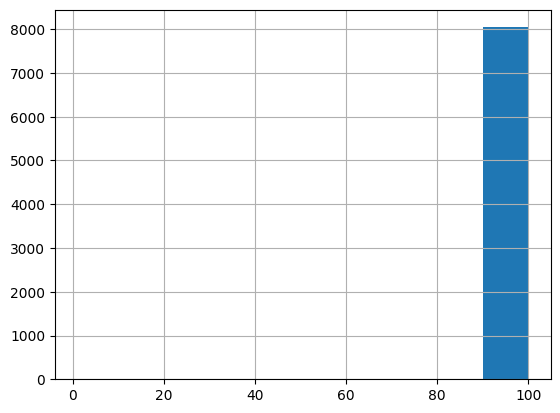

In [18]:
df['Round Lot Size'].hist()

,Symbol,Security Name,Listing Exchange,Market Category,ETF,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,A,"Agilent Technologies, Inc. Common Stock",N,,N,N,NaN,A,A,N
1,AA,Alcoa Corporation Common Stock,N,,N,N,NaN,AA,AA,N
2,AAAU,Perth Mint Physical Gold ETF,P,,Y,N,NaN,AAAU,AAAU,N
3,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,N,N,NaN,AACG,N
4,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,N,NaN,AADR,AADR,N


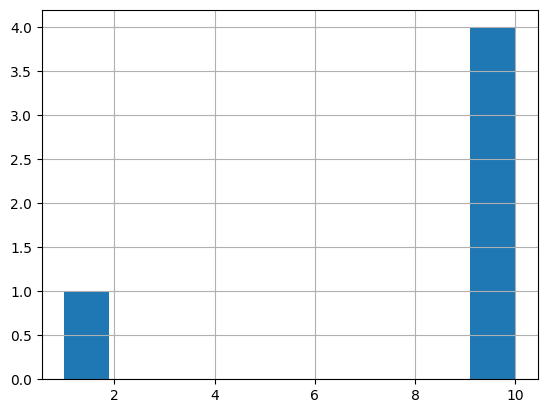

In [33]:
df_temp = df[df['Round Lot Size'] <100]
df_temp['Round Lot Size'].hist()

df.drop(['Round Lot Size'], axis=1, inplace=True)
df.head()

In [36]:
df.drop(['Financial Status', 'Market Category', ], axis=1, inplace=True)
df.head()

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,ETF,Round Lot Size,Test Issue,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,N,100.0,N,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,N,100.0,N,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,Y,100.0,N,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,N,100.0,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,Y,100.0,N,AADR,AADR,N


In [38]:
df.drop(['Nasdaq Traded'], axis=1, inplace=True)

In [69]:
df_temp = df[df['ETF']=='N']
stocks = {}
for i in df_temp['NASDAQ Symbol']:
    stocks[i] = pd.read_csv(path + "/" + "stocks" + "/" + i + ".csv")


<h2>Starting off small with just top 10 stocks and their 5 years of data</h2>

In [79]:
top_10_Symbols = [
    'AAPL', 
    'MSFT',
    'AMZN',
    'GOOGL',
    'FB',
    'TSLA',
    'NFLX',
    'NVDA',
    'ADBE',
    'PYPL'
]
top_10_df = [
    [i,stocks[i]] for i in top_10_Symbols if i in stocks.keys()
]



In [80]:
print(top_10_df[0][1].head())  

        Date      Open      High       Low     Close  Adj Close       Volume
0 1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400.0
1 1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200.0
2 1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000.0
3 1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400.0
4 1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400.0


In [120]:
def generate_price_summary(df, ticker):
    
    summaries = []
    for _, row in df.iterrows():
        if(row['Open'] == 0 or row['Close'] == 0):
            continue
        delta = round((row['Close'] - row['Open']) / row['Open'] * 100, 2)
        direction = "rose" if delta > 0 else "dropped"
        try:
            text = (
                f"On {row['Date'].strftime('%Y-%m-%d')}, {ticker} opened at ${round(row['Open'],2)} and closed at ${round(row['Close'],2)}, "
                f"{direction} by {abs(delta)}%. Volume was {row['Volume']}."
            )

            metadata = {
            "ticker": ticker,
            "date": row["Date"].strftime('%Y-%m-%d'),
            "movement": abs(delta),
            "delta_type": "rise" if delta > 0 else "drop",
            "volume": row["Volume"]
        }
        except:
            text = (
                f"On {row['Date']}, {ticker} opened at ${round(row['Open'],2)} and closed at ${round(row['Close'],2)}, "
                f"{direction} by {abs(delta)}%. Volume was {row['Volume']}."
            )
            metadata = {
                "ticker": ticker,
                "date": row["Date"],
                "movement": abs(delta),
                "delta_type": "rise" if delta > 0 else "drop",
                "volume": row["Volume"]
            }
        summaries.append((text, metadata))
    return summaries

In [81]:
print(top_10_df[0][1])

           Date        Open        High         Low       Close   Adj Close  \
0    1980-12-12    0.513393    0.515625    0.513393    0.513393    0.406782   
1    1980-12-15    0.488839    0.488839    0.486607    0.486607    0.385558   
2    1980-12-16    0.453125    0.453125    0.450893    0.450893    0.357260   
3    1980-12-17    0.462054    0.464286    0.462054    0.462054    0.366103   
4    1980-12-18    0.475446    0.477679    0.475446    0.475446    0.376715   
...         ...         ...         ...         ...         ...         ...   
9904 2020-03-26  246.520004  258.679993  246.360001  258.440002  258.440002   
9905 2020-03-27  252.750000  255.869995  247.050003  247.740005  247.740005   
9906 2020-03-30  250.740005  255.520004  249.399994  254.809998  254.809998   
9907 2020-03-31  255.600006  262.489990  252.000000  254.289993  254.289993   
9908 2020-04-01  246.500000  248.720001  239.130005  240.910004  240.910004   

           Volume  
0     117258400.0  
1      4397

In [82]:
count = 0
for _,i in top_10_df:
    i['Date'] = pd.to_datetime(i['Date'])

    i['Volume'] = i['Volume'].astype(float)
    i = i[(i['Date']> '2015-01-01') & (i['Date']< '2020-01-01')]
    top_10_df[count][1] = i
    count += 1

In [ ]:
print(top_10_df[0][1].describe())

In [113]:
for i in stocks.keys():
    print(i)
    break

A


In [ ]:
import json
all_summaries = []
for stock_data in stocks.keys():
    ticker = stock_data
    df = stocks[stock_data]
    
    # Apply the generate_price_summary function to the first 5 rows (or all rows depending on your choice)
    summaries = generate_price_summary(df, ticker)
    
    # Append the summaries to the list
    all_summaries.extend(summaries)

# Store the summaries in a JSON file
with open("all_stock_summaries.json", "w") as file:
    json.dump(all_summaries, file, indent=4)

In [4]:
!pip install pinecone-client


[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from pinecone import Pinecone
load_dotenv()
pc = Pinecone(api_key = os.getenv("PINECONE_API_KEY"))
index = pc.Index(os.getenv("PINECONE_TICKER_INDEX_NAME"))

In [6]:
from openai import OpenAI


client = OpenAI()
text = client.embeddings.create(
  model="text-embedding-3-small",
  input="The food was delicious and the waiter...",
  encoding_format="float"
)
print(text.data[0])

Embedding(embedding=[-0.029852388, 0.00078823726, -0.08126111, -0.06542928, 0.035152026, -0.034436464, -0.011046502, 0.040831808, -0.034123406, -0.051609974, 0.011571993, -0.020952575, -0.0038433552, -0.030299615, 0.022920374, 0.003471598, 0.011549632, -0.013059023, 0.0018000879, 0.03588995, 0.024955256, -0.0007309363, -0.024284415, 0.013908753, -0.007837649, 0.0032899121, -0.02002458, 0.001393391, -0.012131027, -0.018593455, 0.025245953, -0.006607776, 0.022551412, -0.019074224, -0.04906078, -0.026162768, 0.0587656, 0.0040949206, 0.02486581, 0.011694981, -0.024217332, 0.06945432, 0.05907866, 0.0154293245, 0.04973162, 0.0064065238, -0.04856883, 0.020605976, -0.0023563262, -0.033519648, 0.014937375, 0.018280396, -0.001467463, 0.061180625, -0.0023074108, 0.010057013, 0.026766524, 0.008966898, 0.04056347, -0.01869408, 0.06999099, 0.01501564, -0.0018490033, 0.009089884, -0.017039342, -0.032155607, -0.035308555, -0.0057161176, 0.014098825, -0.036270093, 0.03325131, 0.03723163, -0.04704826, -

In [3]:
def date_to_int(date_str):
    return int(datetime.strptime(date_str, "%Y-%m-%d").strftime("%Y%m%d"))

In [12]:
import json
from tqdm import tqdm 
client
openai.api_key = os.getenv("OPENAI_API_KEY")
EMBEDDING_MODEL = "text-embedding-3-small"

# Load your summaries
with open("top_stock_summaries.json", "r") as file:
    summaries = json.load(file)

# Prepare and upload embeddings to Pinecone
batch_size = 100
vectors = []

for i, summary in enumerate(tqdm(summaries)):
    if i < 4498:
        continue
    text = summary[0]
    embedding = client.embeddings.create(
    model="text-embedding-3-small",
    input=text,
    encoding_format="float"
    ).data[0].embedding
    vectors.append({
        "id": f"{summary[1]['ticker']}_{summary[1]['date']}",
        "values": embedding,
        "metadata": {
            "ticker": summary[1]['ticker'],
            "date": date_to_int(summary[1]['date']),
            "text": text
        }
    })

    # Upload in batches
    if len(vectors) == batch_size or i == len(summaries) - 1:
        index.upsert(vectors=vectors)
        vectors = []

print("✅ Embeddings uploaded to Pinecone.")


 70%|██████▉   | 8697/12454 [49:13<21:16,  2.94it/s]  


ProtocolError: Failed to connect; did you specify the correct index name?